In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_excel("sample_data_cleaning_project.xlsx")

In [13]:
df.head()

,Name,Age,Salary,Join_Date,Department
0,Pam,25.0,70200.0,2023-01-15,HR
1,Jane,NaN,65000.0,2022-08-01,Finance
2,Alice,22.0,71350.0,2021-05-20,HR
3,Bob,22.0,NaN,2023-01-15,IT
4,Pam,25.0,71250.0,2023-01-15,HR


In [14]:
df.shape

(43, 5)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Name        43 non-null     str           
 1   Age         39 non-null     float64       
 2   Salary      36 non-null     float64       
 3   Join_Date   43 non-null     datetime64[us]
 4   Department  43 non-null     str           
dtypes: datetime64[us](1), float64(2), str(2)
memory usage: 1.8 KB


In [16]:
df.columns

Index(['Name', 'Age', 'Salary', 'Join_Date', 'Department'], dtype='str')

In [17]:
df.isnull().sum()

Name          0
Age           4
Salary        7
Join_Date     0
Department    0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(1)

In [19]:
df.describe()

,Age,Salary,Join_Date
count,39.000000,36.000000,43
mean,34.692308,132729.694444,2022-08-07 21:12:33.488372
min,21.000000,61000.000000,2021-02-04 00:00:00
25%,25.000000,66175.000000,2022-03-04 00:00:00
50%,36.000000,71841.000000,2022-10-01 00:00:00
75%,42.000000,77421.000000,2023-01-15 00:00:00
max,57.000000,921000.000000,2024-10-03 00:00:00
std,9.624951,196694.464572,NaN


In [20]:
df[df['Age'].isnull()]

,Name,Age,Salary,Join_Date,Department
1,Jane,NaN,65000.0,2022-08-01,Finance
9,Eli,NaN,80100.0,2022-03-04,HR
14,Pamela,NaN,77421.0,2023-04-02,HR
24,Tony,NaN,66200.0,2023-05-18,Finance


In [21]:
df[df['Salary'].isnull()]

,Name,Age,Salary,Join_Date,Department
3,Bob,22.0,NaN,2023-01-15,IT
5,Jade,40.0,NaN,2023-01-15,Finance
8,Sam,40.0,NaN,2022-09-05,IT
12,Dan,43.0,NaN,2023-01-15,HR
17,Dan,43.0,NaN,2022-05-03,HR
31,Sam,40.0,NaN,2022-09-05,IT
40,Anna,36.0,NaN,2022-04-06,HR


In [27]:
df[df.duplicated(keep=False)]

,Name,Age,Salary,Join_Date,Department


In [23]:
df = df.drop_duplicates()

In [26]:
df.duplicated().sum()

np.int64(0)

In [28]:
df['Age'].median()

np.float64(36.0)

In [30]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [31]:
df['Age'].isnull().sum()

np.int64(0)

In [32]:
df['Salary'].median()

np.float64(71841.0)

In [34]:
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

In [35]:
df['Salary'].isnull().sum()

np.int64(0)

In [37]:
df = df.drop_duplicates()

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df['Age'].median()

np.float64(36.0)

In [40]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [41]:
df['Salary'].median()

np.float64(71841.0)

In [42]:
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

In [43]:
df.isnull().sum()

Name          0
Age           0
Salary        0
Join_Date     0
Department    0
dtype: int64

In [48]:
df['Salary'].sort_values(ascending=False).head(10)

21    921000.0
28    801423.0
42    546222.0
15    126001.0
18    125600.0
6     120000.0
41     86548.0
9      80100.0
14     77421.0
23     77421.0
Name: Salary, dtype: float64

In [49]:
df[['Name', 'Age', 'Salary', 'Department']].sort_values(
    by='Salary', ascending=False
).head(10)

,Name,Age,Salary,Department
21,Norma,51.0,921000.0,IT
28,Jenny,36.0,801423.0,IT
42,Kim,33.0,546222.0,HR
15,Susy,41.0,126001.0,IT
18,Joanne,25.0,125600.0,IT
6,Joanne,25.0,120000.0,IT
41,Pam,25.0,86548.0,HR
9,Eli,36.0,80100.0,HR
14,Pamela,36.0,77421.0,HR
23,Eli,21.0,77421.0,HR


In [50]:
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 68500.0
Q3: 77421.0
IQR: 8921.0
Lower Bound: 55118.5
Upper Bound: 90802.5


In [51]:
outliers = df[
    (df['Salary'] < lower_bound) |
    (df['Salary'] > upper_bound)
]

outliers[['Name', 'Age', 'Salary', 'Department']]

,Name,Age,Salary,Department
6,Joanne,25.0,120000.0,IT
15,Susy,41.0,126001.0,IT
18,Joanne,25.0,125600.0,IT
21,Norma,51.0,921000.0,IT
28,Jenny,36.0,801423.0,IT
42,Kim,33.0,546222.0,HR


In [55]:
df['Salary_Outlier'] = (
    (df['Salary'] < lower_bound) |
    (df['Salary'] > upper_bound)
)

In [56]:
df[['Name', 'Salary', 'Salary_Outlier']]

,Name,Salary,Salary_Outlier
0,Pam,70200.0,False
1,Jane,65000.0,False
2,Alice,71350.0,False
3,Bob,71841.0,False
4,Pam,71250.0,False
5,Jade,71841.0,False
6,Joanne,120000.0,True
7,Kim,71568.0,False
8,Sam,71841.0,False
9,Eli,80100.0,False


In [57]:
df.dtypes

Name                         str
Age                      float64
Salary                   float64
Join_Date         datetime64[us]
Department                   str
Salary_Outlier              bool
dtype: object

In [58]:
df['Join_Date'] = pd.to_datetime(df['Join_Date'])

In [59]:
df['Join_Date'].dtype

dtype('<M8[us]')

In [60]:
df['Department'].value_counts()

Department
HR         22
Finance    10
IT         10
Name: count, dtype: int64

In [61]:
df['Department'].unique()

<StringArray>
['HR', 'Finance', 'IT']
Length: 3, dtype: str

In [62]:
df['Name'].str.strip().unique()

<StringArray>
[     'Pam',     'Jane',    'Alice',      'Bob',     'Jade',   'Joanne',
      'Kim',      'Sam',      'Eli',      'Joe',     'Anna',      'Dan',
    'Susan',   'Pamela',     'Susy',     'Ruth',    'Clark',   'Alissa',
    'Norma',  'Anthony',     'Tony', 'Samantha',   'Amanda',    'Jenny',
    'Penny',    'Jimmy',      'Tim',     'Fran',    'Timmy',    'Sammy']
Length: 30, dtype: str

In [63]:
df['Name'] = df['Name'].str.strip()
df['Department'] = df['Department'].str.strip()

In [64]:
df[['Name', 'Department']].head()

,Name,Department
0,Pam,HR
1,Jane,Finance
2,Alice,HR
3,Bob,IT
4,Pam,HR


In [65]:
df.isnull().sum()

Name              0
Age               0
Salary            0
Join_Date         0
Department        0
Salary_Outlier    0
dtype: int64

In [66]:
df.duplicated().sum()

np.int64(0)

In [67]:
df.shape

(42, 6)

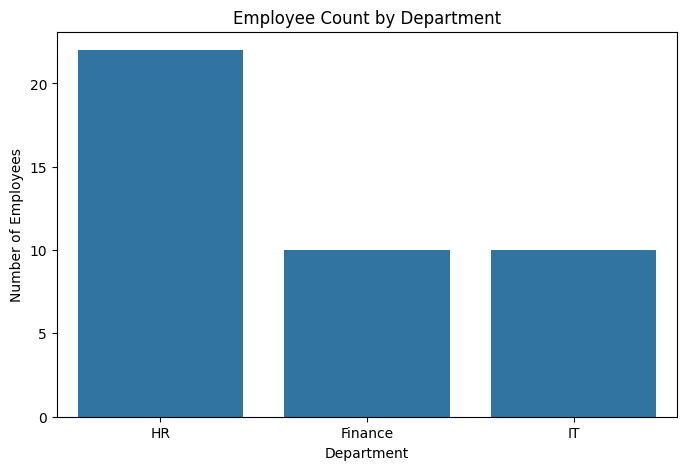

In [68]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Department')

plt.title('Employee Count by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')

plt.show()

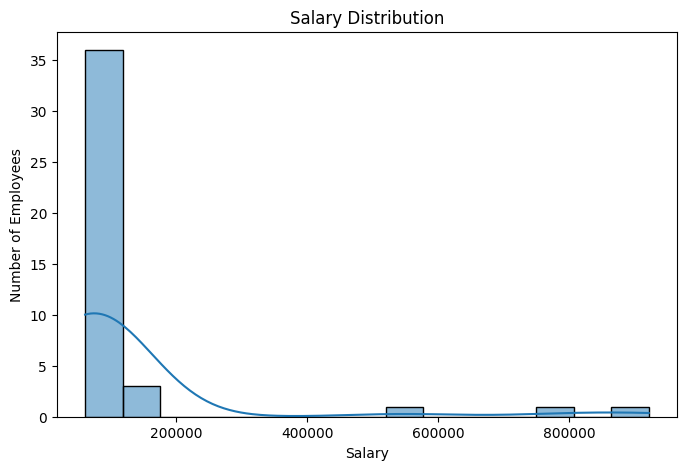

In [69]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='Salary', bins=15, kde=True)

plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Number of Employees')

plt.show()

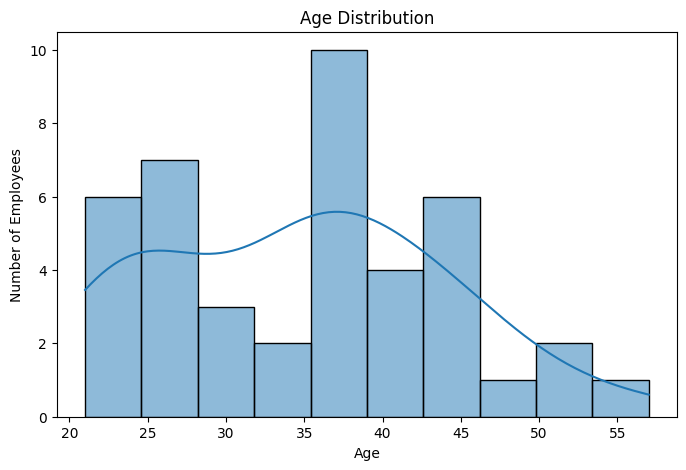

In [71]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='Age', bins=10, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Employees')

plt.show()

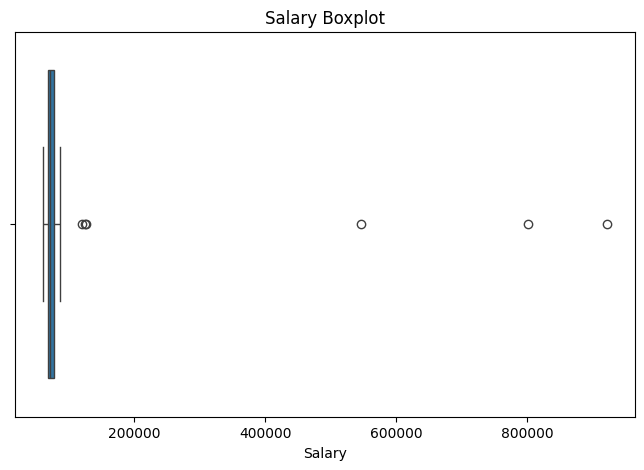

In [72]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df['Salary'])

plt.title('Salary Boxplot')
plt.xlabel('Salary')

plt.show()

In [73]:
df[df['Salary_Outlier']][
    ['Name', 'Age', 'Salary', 'Department']
]

,Name,Age,Salary,Department
6,Joanne,25.0,120000.0,IT
15,Susy,41.0,126001.0,IT
18,Joanne,25.0,125600.0,IT
21,Norma,51.0,921000.0,IT
28,Jenny,36.0,801423.0,IT
42,Kim,33.0,546222.0,HR


In [74]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Potential salary outliers:", df['Salary_Outlier'].sum())

Rows: 42
Columns: 6
Missing values: 0
Duplicate rows: 0
Potential salary outliers: 6


In [75]:
df.to_excel("cleaned_employee_data.xlsx", index=False)

In [76]:
import os

os.path.exists("cleaned_employee_data.xlsx")

True

In [77]:
df.to_csv("cleaned_employee_data.csv", index=False)

In [78]:
os.path.exists("cleaned_employee_data.csv")

True